# IA para Classificação de Risco de Falha Mecânica em Máquinas Industriais

**Objetivo:** treinar, do zero (sem frameworks de deep learning), um neurônio artificial (regressão logística implementada manualmente) que estima a probabilidade de falha mecânica em máquinas industriais a partir de parâmetros sensoriais.

**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset) (UCI Machine Learning Repository). É um dataset sintético estruturado para refletir de forma realista dados reais de manutenção industrial — amplamente usado em pesquisa e benchmarks de manutenção preditiva.

**O que este notebook mostra:**
1. Carregamento e exploração do dataset real
2. Implementação de um neurônio artificial (sigmoide + regra delta) treinado manualmente com múltiplas variáveis
3. Tratamento do desbalanceamento de classes (falhas são só ~3.4% dos dados)
4. Avaliação com métricas adequadas (recall/precisão, não só acurácia)
5. Comparação com `LogisticRegression` do scikit-learn
6. Sistema de alertas automáticos e painéis interativos de simulação de risco


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Carregando o dataset real (AI4I 2020 - UCI)

In [2]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=601)
df = dataset.data.features.copy()
df['Machine failure'] = dataset.data.targets['Machine failure']

print(df.columns.tolist())

df.head()


['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## 2. Análise exploratória rápida

In [3]:
def encontrar_coluna(df, chave):
    for col in df.columns:
        if chave.lower() in col.lower():
            return col
    raise KeyError(f"Coluna contendo '{chave}' não encontrada. Colunas disponíveis: {df.columns.tolist()}")

nomes_chave = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
colunas_usadas = [encontrar_coluna(df, chave) for chave in nomes_chave]
print("Colunas selecionadas:", colunas_usadas)

print("Formato do dataset:", df.shape)
print("\nProporção de falhas:")
print(df['Machine failure'].value_counts(normalize=True))

df[colunas_usadas].describe()


Colunas selecionadas: ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
Formato do dataset: (10000, 7)

Proporção de falhas:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


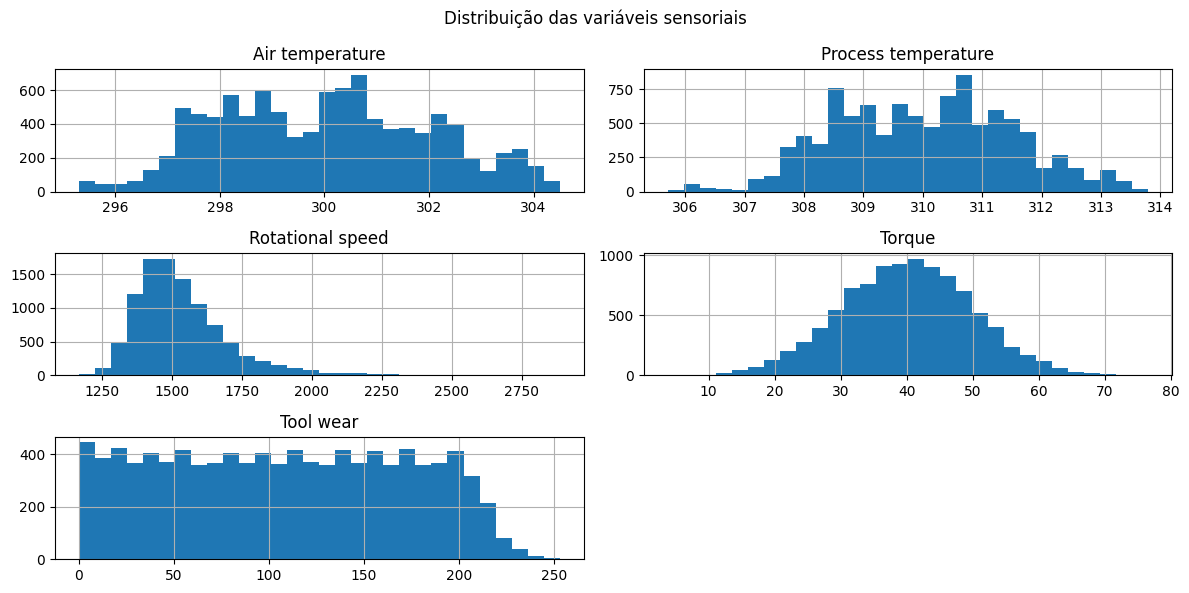

In [4]:
df[colunas_usadas].hist(figsize=(12, 6), bins=30)
plt.suptitle("Distribuição das variáveis sensoriais")
plt.tight_layout()
plt.show()


**Observação importante:** apenas ~3.4% das máquinas apresentam falha nesse dataset. Isso é desbalanceamento de classes real — se ignorarmos isso, o modelo pode "aprender" a sempre prever "sem falha" e ainda assim parecer ter alta acurácia (esconde o problema em vez de resolvê-lo).

## 3. Preparando os dados

In [5]:
X = df[colunas_usadas].to_numpy()
y = df['Machine failure'].to_numpy()

def normalizar(X):
    media = X.mean(axis=0)
    desvio = X.std(axis=0)
    return (X - media) / desvio, media, desvio

X_norm, media, desvio = normalizar(X)

print("X normalizado:", X_norm.shape)


X normalizado: (10000, 5)


## 4. Treinamento do neurônio (regra delta) — multivariável e ponderado por classe

Diferente de uma versão simples, aqui:
- O treinamento usa as **5 variáveis simultaneamente** (não só temperatura)
- Apliquei um **peso maior para a classe minoritária (falha)**, proporcional ao desbalanceamento — sem isso, o gradiente é dominado pelos exemplos "sem falha" e o modelo nunca aprende a detectar falha de verdade.

In [6]:
pesos = np.zeros(X.shape[1])
bias = 0.0
taxa_aprendizado = 0.1
epocas = 500
historico_erro = []

# Peso maior para a classe minoritária (falha), proporcional ao desbalanceamento
peso_falha = (1 - y.mean()) / y.mean()
pesos_amostra = np.where(y == 1, peso_falha, 1.0)

for epoca in range(epocas):
    z = np.dot(X_norm, pesos) + bias
    pred = 1 / (1 + np.exp(-z))
    erro = (y - pred) * pesos_amostra

    pesos += taxa_aprendizado * np.dot(X_norm.T, erro) / len(y)
    bias += taxa_aprendizado * erro.mean()

    perda = -np.mean(pesos_amostra * (y * np.log(pred + 1e-9) + (1 - y) * np.log(1 - pred + 1e-9)))
    historico_erro.append(perda)

print("Pesos aprendidos:", pesos)
print("Bias aprendido:", bias)


Pesos aprendidos: [ 1.39462816 -0.87521651  1.5473247   2.19256761  0.83435003]
Bias aprendido: -1.3020816842372993


## 5. Avaliação — recall e precisão em vez de só acurácia

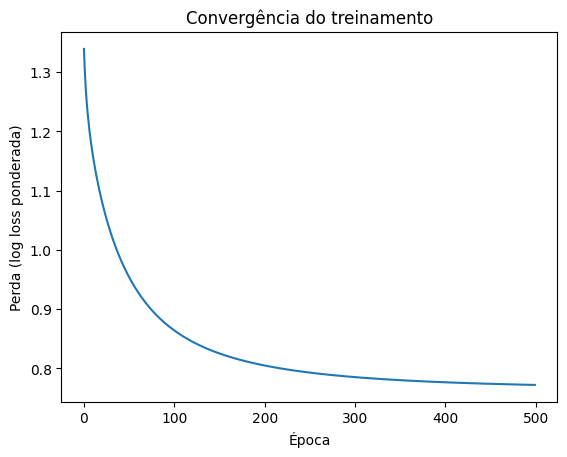

Acurácia: 81.6%  (cuidado: enganosa em dados desbalanceados)
Recall (falhas detectadas corretamente): 82.0%
Precisão: 13.5%


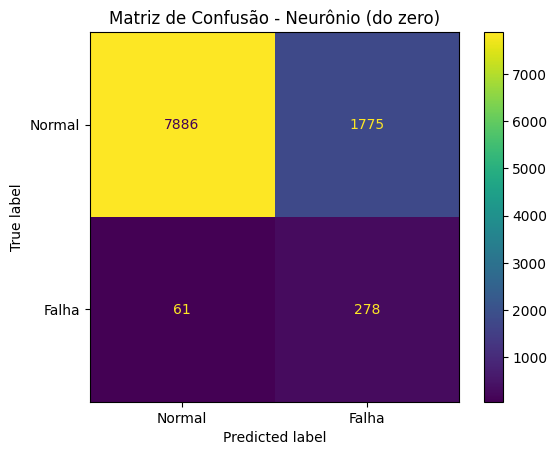

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score

plt.plot(historico_erro)
plt.xlabel("Época")
plt.ylabel("Perda (log loss ponderada)")
plt.title("Convergência do treinamento")
plt.show()

pred_final = (1 / (1 + np.exp(-(np.dot(X_norm, pesos) + bias)))) >= 0.5

print(f"Acurácia: {(pred_final == y).mean():.1%}  (cuidado: enganosa em dados desbalanceados)")
print(f"Recall (falhas detectadas corretamente): {recall_score(y, pred_final):.1%}")
print(f"Precisão: {precision_score(y, pred_final, zero_division=0):.1%}")

cm = confusion_matrix(y, pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Falha"]).plot()
plt.title("Matriz de Confusão - Neurônio (do zero)")
plt.show()


## 6. Comparação com scikit-learn\n\nValida se a implementação manual está correta, comparando com uma biblioteca consolidada (também ajustada para lidar com o desbalanceamento via `class_weight='balanced'`).

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelo_sklearn = LogisticRegression(class_weight='balanced')
modelo_sklearn.fit(X_norm, y)
pred_sklearn = modelo_sklearn.predict(X_norm)

print("Comparação dos dois modelos:")
print(f"  Recall  - meu neurônio: {recall_score(y, pred_final):.1%}   |   sklearn: {recall_score(y, pred_sklearn):.1%}")
print(f"  Precisão - meu neurônio: {precision_score(y, pred_final, zero_division=0):.1%}   |   sklearn: {precision_score(y, pred_sklearn, zero_division=0):.1%}")


Comparação dos dois modelos:
  Recall  - meu neurônio: 82.0%   |   sklearn: 82.6%
  Precisão - meu neurônio: 13.5%   |   sklearn: 13.9%


## 7. Sistema de alertas automáticos (simulação de ação)

In [9]:
def monitorar_e_notificar(id_maquina, dados_sensores, pesos, bias, media, desvio):
    """
    Recebe leituras brutas dos sensores, normaliza com as mesmas estatísticas
    do treino, calcula a probabilidade de falha e simula o disparo de alertas.
    """
    dados_norm = (dados_sensores - media) / desvio
    z = np.dot(dados_norm, pesos) + bias
    prob = 1 / (1 + np.exp(-z))

    print(f"\n--- Status da Máquina [{id_maquina}] ---")
    print(f"Risco Calculado: {prob:.1%}")

    if prob >= 0.70:
        print("🚨 [ALERTA CRÍTICO ENVIADO VIA EMAIL/SMS]")
        print("-> Ação Automática: Ordem de Serviço criada para Manutenção de Emergência.")
    elif prob >= 0.40:
        print("⚠️ [AVISO DE ATENÇÃO]")
        print("-> Ação Automática: Notificação enviada ao painel do supervisor.")
    else:
        print("✅ [STATUS NORMAL]")
        print("-> Nenhum alerta necessário.")

# Exemplo com leituras dentro da mesma escala do dataset (K, rpm, Nm, min)
maquina_A = np.array([308, 316, 1250, 58, 220])  # sobrecarregada
maquina_B = np.array([298, 308, 1550, 35, 20])   # operação normal

monitorar_e_notificar("MQ-101", maquina_A, pesos, bias, media, desvio)
monitorar_e_notificar("MQ-102", maquina_B, pesos, bias, media, desvio)



--- Status da Máquina [MQ-101] ---
Risco Calculado: 97.5%
🚨 [ALERTA CRÍTICO ENVIADO VIA EMAIL/SMS]
-> Ação Automática: Ordem de Serviço criada para Manutenção de Emergência.

--- Status da Máquina [MQ-102] ---
Risco Calculado: 2.5%
✅ [STATUS NORMAL]
-> Nenhum alerta necessário.


## 8. Painel interativo — risco em função do desgaste da ferramenta

In [10]:
import plotly.graph_objects as go

# Fixamos os demais sensores em valores medianos do dataset e variamos o desgaste da ferramenta
fixos = np.array([
    df[colunas_usadas[0]].median(), # 'Air temperature'
    df[colunas_usadas[1]].median(), # 'Process temperature'
    df[colunas_usadas[2]].median(), # 'Rotational speed'
    df[colunas_usadas[3]].median(), # 'Torque'
])

desgaste = np.linspace(0, 250, 100)
fig = go.Figure()

for torque_extra, cor, nome in zip([-10, 0, 15], ['#1f77b4', '#ff7f0e', '#d62728'],
                                     ['Torque baixo', 'Torque mediano', 'Torque alto']):
    entradas = np.column_stack([
        np.full_like(desgaste, fixos[0]),
        np.full_like(desgaste, fixos[1]),
        np.full_like(desgaste, fixos[2]),
        np.full_like(desgaste, fixos[3] + torque_extra),
        desgaste
    ])
    entradas_norm = (entradas - media) / desvio
    z = np.dot(entradas_norm, pesos) + bias
    prob = (1 / (1 + np.exp(-z))) * 100

    fig.add_trace(go.Scatter(x=desgaste, y=prob, mode='lines', name=nome,
                              line=dict(color=cor, width=3)))

fig.add_hline(y=70, line_dash="dash", line_color="red", annotation_text="Risco Crítico (70%)")
fig.add_hline(y=40, line_dash="dash", line_color="orange", annotation_text="Risco Moderado (40%)")

fig.update_layout(
    xaxis_title='Desgaste da Ferramenta (min)',
    yaxis_title='Probabilidade de Falha (%)',
    yaxis=dict(range=[0, 100]),
    template='plotly_white',
    hovermode='x unified',
    height=420
)
fig.show()

## 9. Simulador interativo em tempo real (ipywidgets)

In [11]:
from ipywidgets import interact, FloatSlider

def simular_risco(temperatura_ar, temperatura_processo, velocidade_rpm, torque, desgaste):
    entrada = np.array([temperatura_ar, temperatura_processo, velocidade_rpm, torque, desgaste])
    entrada_norm = (entrada - media) / desvio
    z = np.dot(entrada_norm, pesos) + bias
    prob = (1 / (1 + np.exp(-z))) * 100

    print(f"Probabilidade de Falha: {prob:.1f}%")
    if prob >= 70:
        print("🚨 CRÍTICO")
    elif prob >= 40:
        print("⚠️ ATENÇÃO")
    else:
        print("✅ NORMAL")

interact(
    simular_risco,
    temperatura_ar=FloatSlider(min=295, max=305, step=0.5, value=300, description='Temp. Ar (K):'),
    temperatura_processo=FloatSlider(min=305, max=315, step=0.5, value=310, description='Temp. Processo (K):'),
    velocidade_rpm=FloatSlider(min=1000, max=2800, step=50, value=1500, description='Velocidade (rpm):'),
    torque=FloatSlider(min=0, max=80, step=1, value=40, description='Torque (Nm):'),
    desgaste=FloatSlider(min=0, max=250, step=5, value=100, description='Desgaste (min):')
);


interactive(children=(FloatSlider(value=300.0, description='Temp. Ar (K):', max=305.0, min=295.0, step=0.5), F…

## 10. Análise de sensibilidade do bias

In [12]:
entrada_exemplo = np.array([308, 315, 1200, 55, 210])
entrada_norm = (entrada_exemplo - media) / desvio

print("Como o ajuste do bias muda o risco calculado para a mesma leitura de sensores:\n")
for ajuste in [-2, -1, 0, 1, 2]:
    z = np.dot(entrada_norm, pesos) + (bias + ajuste)
    prob = 1 / (1 + np.exp(-z))
    print(f"Bias ajustado em {ajuste:+d}  ->  Probabilidade de Falha = {prob:.1%}")


Como o ajuste do bias muda o risco calculado para a mesma leitura de sensores:

Bias ajustado em -2  ->  Probabilidade de Falha = 73.9%
Bias ajustado em -1  ->  Probabilidade de Falha = 88.5%
Bias ajustado em +0  ->  Probabilidade de Falha = 95.4%
Bias ajustado em +1  ->  Probabilidade de Falha = 98.3%
Bias ajustado em +2  ->  Probabilidade de Falha = 99.4%


## 11. Bônus: comparando com frameworks de produção (PyTorch e Keras/TensorFlow)

Até aqui, todo o modelo foi implementado manualmente, com NumPy, para entender a matemática por trás de um neurônio artificial (soma ponderada, sigmoide, regra delta).

Nesta seção, foi treinada uma **rede neural com camada oculta (MLP)** para o mesmo problema, usando dois frameworks de produção : **PyTorch** e **Keras/TensorFlow**. O objetivo é comparar:
- Como o mesmo problema é resolvido usando ferramentas prontas (autograd, otimizadores, etc.)
- Se uma arquitetura mais complexa (com camada oculta) melhora o recall/precisão em relação ao neurônio simples

Usando o mesmo dataset (`X_norm`, `y`, `media`, `desvio`) já preparado nas seções anteriores.

### 11.1 PyTorch

In [13]:
!pip install torch -q

import torch
import torch.nn as nn

torch.manual_seed(42)

X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.camadas = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)  # logit puro; a sigmoide é aplicada dentro da loss
        )

    def forward(self, x):
        return self.camadas(x)

modelo_pytorch = MLP(X_norm.shape[1])

# Mesmo princípio de peso de classe usado no neurônio manual, aqui via pos_weight
peso_falha = (1 - y.mean()) / y.mean()
pos_weight = torch.tensor([peso_falha], dtype=torch.float32)
criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
otimizador = torch.optim.Adam(modelo_pytorch.parameters(), lr=0.01)

epocas = 100
historico_perda_pytorch = []

for epoca in range(epocas):
    otimizador.zero_grad()
    saida = modelo_pytorch(X_tensor)
    perda = criterio(saida, y_tensor)
    perda.backward()
    otimizador.step()
    historico_perda_pytorch.append(perda.item())

print("Perda final (PyTorch):", historico_perda_pytorch[-1])


Perda final (PyTorch): 0.39737221598625183


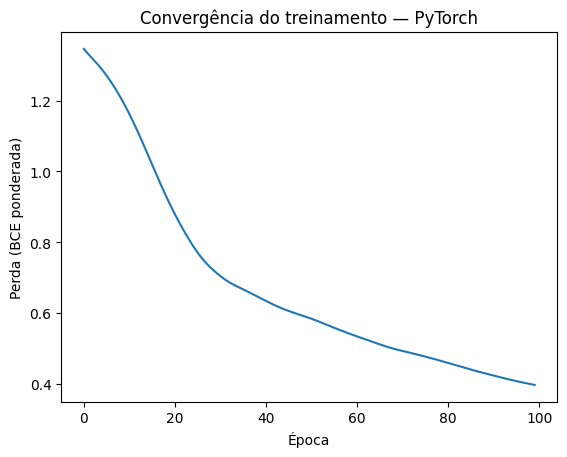

Recall (PyTorch):    93.5%
Precisão (PyTorch):  26.3%


In [14]:
plt.plot(historico_perda_pytorch)
plt.xlabel("Época")
plt.ylabel("Perda (BCE ponderada)")
plt.title("Convergência do treinamento — PyTorch")
plt.show()

with torch.no_grad():
    probs_pytorch = torch.sigmoid(modelo_pytorch(X_tensor)).numpy().flatten()
pred_pytorch = probs_pytorch >= 0.5

print(f"Recall (PyTorch):    {recall_score(y, pred_pytorch):.1%}")
print(f"Precisão (PyTorch):  {precision_score(y, pred_pytorch, zero_division=0):.1%}")


### 11.2 Keras / TensorFlow

In [15]:
!pip install keras -q

import tensorflow as tf
import keras
from keras import layers

tf.random.set_seed(42)

modelo_keras = keras.Sequential([
    layers.Input(shape=(X_norm.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

modelo_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

peso_falha = (1 - y.mean()) / y.mean()
pesos_classe = {0: 1.0, 1: peso_falha}

historico_keras = modelo_keras.fit(
    X_norm, y,
    epochs=30,
    batch_size=64,
    class_weight=pesos_classe,
    verbose=0
)

print("Perda final (Keras):", historico_keras.history['loss'][-1])

Perda final (Keras): 0.33543017506599426


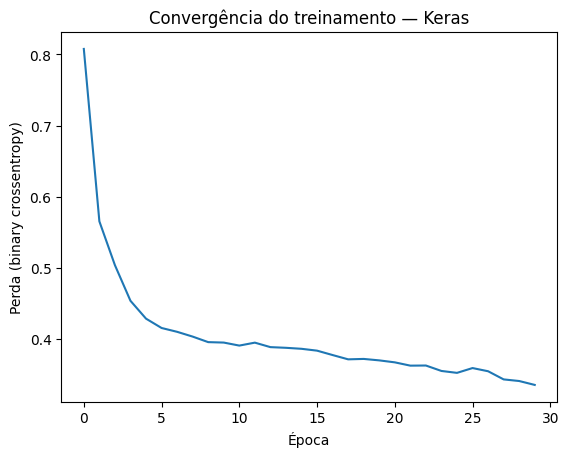

Recall (Keras):    90.0%
Precisão (Keras):  39.8%


In [16]:
plt.plot(historico_keras.history['loss'])
plt.xlabel("Época")
plt.ylabel("Perda (binary crossentropy)")
plt.title("Convergência do treinamento — Keras")
plt.show()

pred_keras = (modelo_keras.predict(X_norm, verbose=0) >= 0.5).flatten()

print(f"Recall (Keras):    {recall_score(y, pred_keras):.1%}")
print(f"Precisão (Keras):  {precision_score(y, pred_keras, zero_division=0):.1%}")


### 11.3 Comparação final entre os três modelos

| Modelo | O que representa |
|---|---|
| Neurônio manual (NumPy) | Implementação própria, sem framework — mostra domínio da matemática |
| PyTorch (MLP) | Rede com camada oculta, framework flexível usado em pesquisa e produção |
| Keras/TensorFlow (MLP) | Rede com camada oculta, framework de alto nível usado em produção |

Todos os três foram treinados com a **mesma lógica de peso de classe** para lidar com o desbalanceamento (~3,4% de falhas), o que torna a comparação justa.

In [17]:
print("Recall / Precisão — comparação final\n")
print(f"Neurônio manual (NumPy):  recall={recall_score(y, pred_final):.1%}   precisão={precision_score(y, pred_final, zero_division=0):.1%}")
print(f"PyTorch (MLP):            recall={recall_score(y, pred_pytorch):.1%}   precisão={precision_score(y, pred_pytorch, zero_division=0):.1%}")
print(f"Keras/TensorFlow (MLP):   recall={recall_score(y, pred_keras):.1%}   precisão={precision_score(y, pred_keras, zero_division=0):.1%}")


Recall / Precisão — comparação final

Neurônio manual (NumPy):  recall=82.0%   precisão=13.5%
PyTorch (MLP):            recall=93.5%   precisão=26.3%
Keras/TensorFlow (MLP):   recall=90.0%   precisão=39.8%


## Conclusão

Este notebook evoluiu de um exemplo didático com pesos manuais e dados para um pipeline completo que:
- Usa um dataset público real de referência (AI4I 2020, UCI)
- Trata desbalanceamento de classes de forma explícita
- Valida a implementação "do zero" comparando com scikit-learn
- Compara com redes neurais (MLP) treinadas em **PyTorch** e **Keras/TensorFlow**, mostrando domínio tanto da matemática quanto das ferramentas de produção
- Conecta o modelo treinado a um sistema de alertas e painéis de simulação

**Próximos passos possíveis:** validação cruzada e conjunto de teste separado (aqui avaliamos no próprio conjunto de treino, por simplicidade didática), testar outros limiares de decisão além de 0.5, e experimentar arquiteturas mais profundas ou outras técnicas de balanceamento (ex: SMOTE).